In [2]:
import os
import paramiko
from tqdm import tqdm
import pandas as pd
import glob
import ast
import numpy as np
from matplotlib import pyplot as plt

paramiko.DSSKey = None

camp_ids = {
    '10K': 189,
    '30K': 190,
    '100K': 191,
    '3K': 193,
}
macs_node = {
    '1': 'd8:3a:dd:f7:1d:f2',
    '3': 'd8:3a:dd:f7:22:87',
    '4': 'd8:3a:dd:f6:fc:be',
    '5': 'd8:3a:dd:f7:21:52',
    '9': 'd8:3a:dd:f4:4e:d1',
}

In [3]:
!git clone https://github.com/dramirezbe/RBW_campaigns.git

Cloning into 'RBW_campaigns'...
remote: Enumerating objects: 26, done.
remote: Total 26 (delta 0), reused 0 (delta 0), pack-reused 26 (from 1)
Receiving objects: 100% (26/26), 50.93 MiB | 16.13 MiB/s, done.


In [4]:
# 1. CARGA (Ruta corregida)
archivos = glob.glob("RBW_campaigns/*/Node*.csv") 
df_full = {}

for archivo in tqdm(archivos, desc="Cargando CSVs"):
    nombre_nodo = os.path.basename(archivo).replace('.csv', '')
    rbw = os.path.basename(os.path.dirname(archivo)) 
    
    df = pd.read_csv(archivo)
    df['pxx'] = df['pxx'].apply(ast.literal_eval) 
    
    if rbw not in df_full:
        df_full[rbw] = {} 
        
    df_full[rbw][nombre_nodo] = df

Cargando CSVs:   0%|          | 0/20 [00:00<?, ?it/s]

Cargando CSVs: 100%|██████████| 20/20 [00:25<00:00,  1.28s/it]


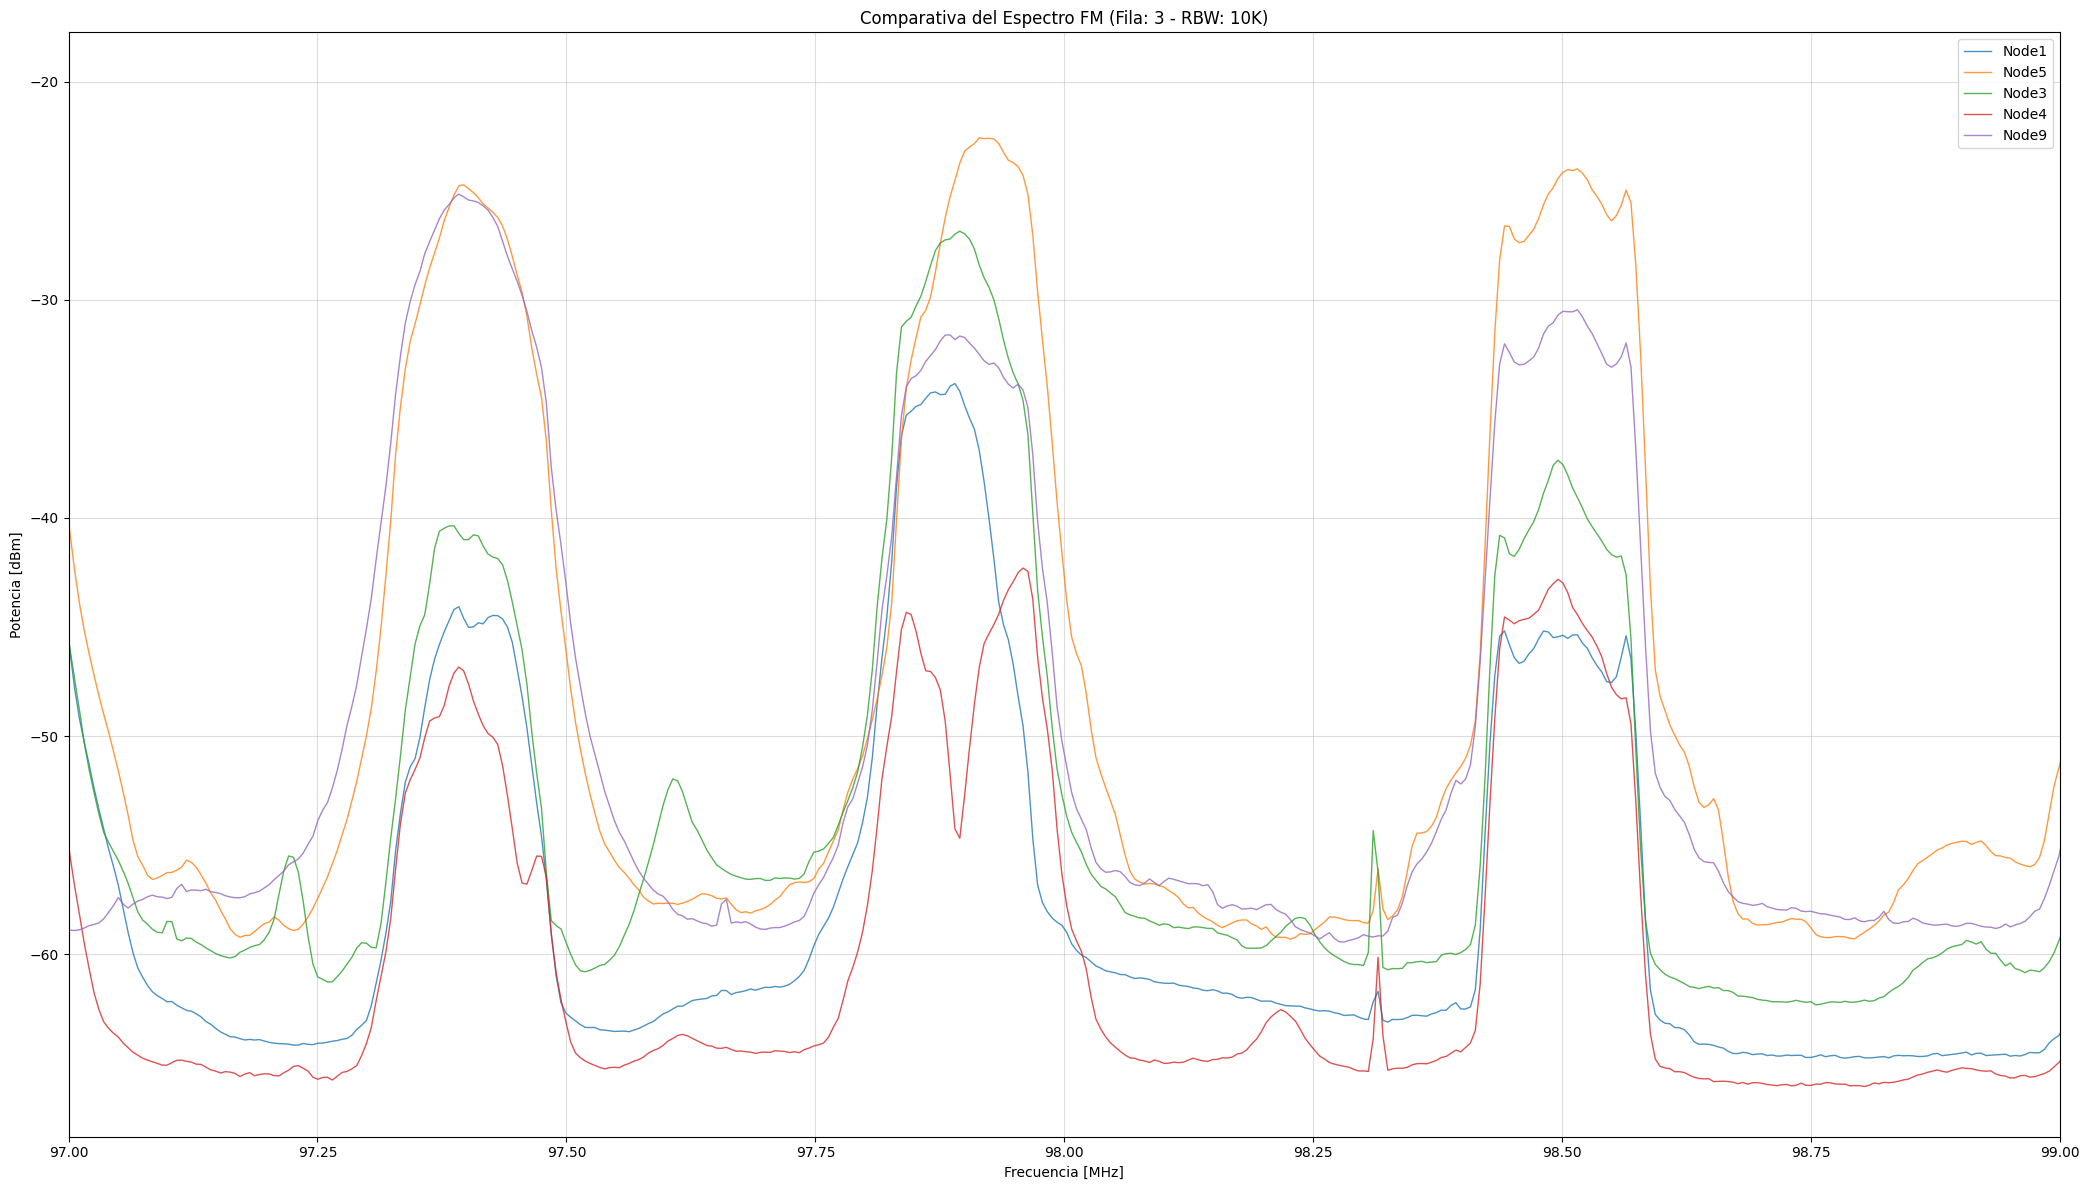

In [5]:
# 2. GRÁFICA
RBW = "10K"  
datos_nodos = df_full[RBW]

ROW_PLOT = 3  
plt.figure(figsize=(21, 12))

for nombre_nodo, df in datos_nodos.items():
    pxx = df['pxx'].iloc[ROW_PLOT] 
    frecuencias = np.linspace(88, 108, len(pxx))
    
    plt.plot(frecuencias, pxx, label=nombre_nodo, linewidth=1, alpha=0.8)

plt.title(f"Comparativa del Espectro FM (Fila: {ROW_PLOT} - RBW: {RBW})")
plt.xlabel("Frecuencia [MHz]")
plt.ylabel("Potencia [dBm]")
plt.xlim(97, 99)
plt.legend(loc='best')
plt.grid(True, alpha=0.42)
plt.tight_layout()
plt.show()

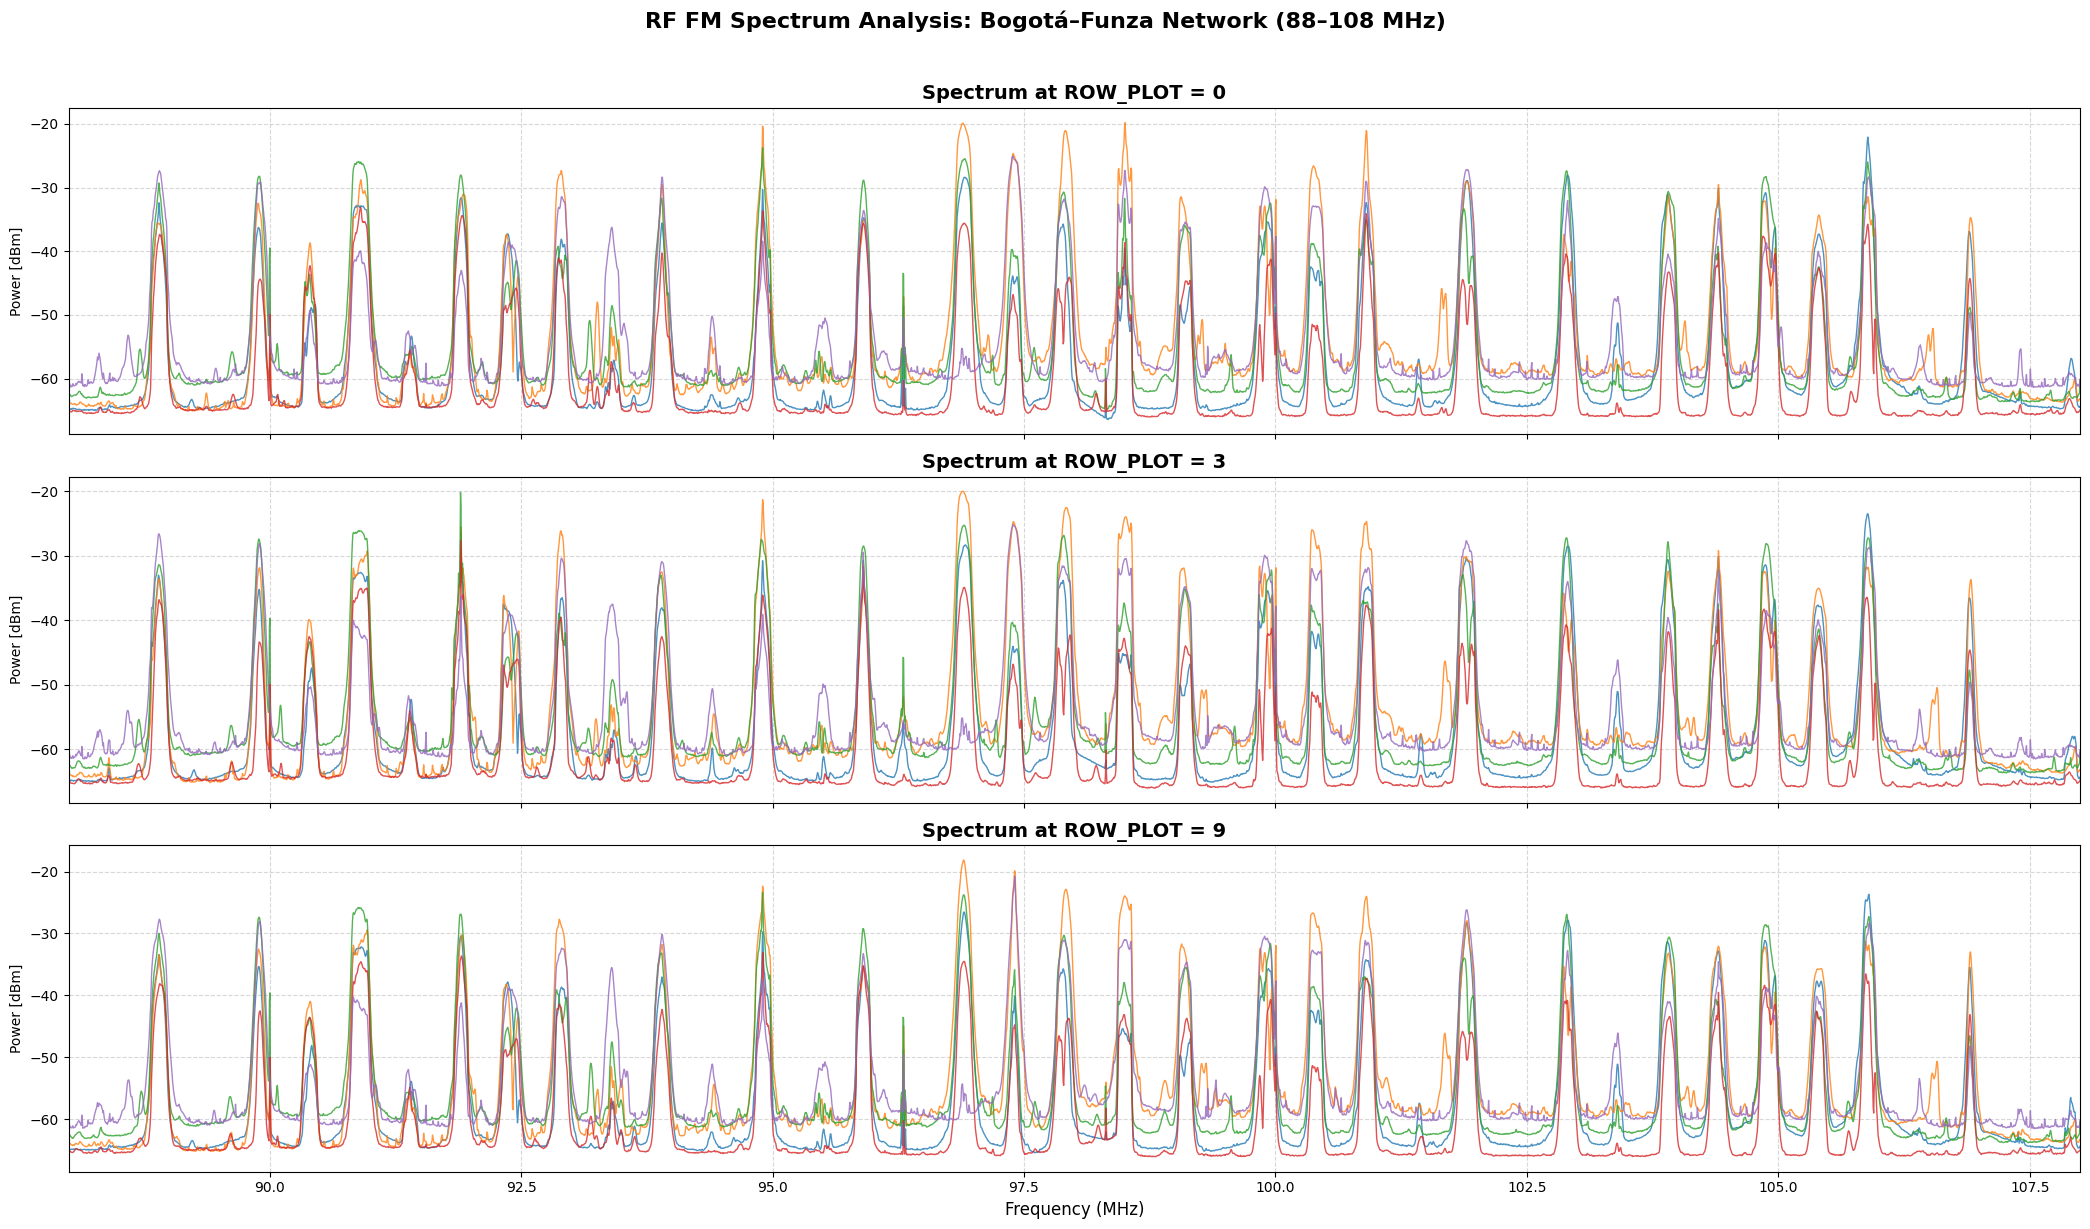

In [6]:
# Row indices to plot
row_indices = [0, 3, 9]

# Create figure with 3 subplots (one per ROW_PLOT value)
fig, axes = plt.subplots(nrows=len(row_indices), ncols=1, figsize=(21, 12), sharex=True)

# Ensure axes is iterable even if only one row
if len(row_indices) == 1:
    axes = [axes]

for ax, row_idx in zip(axes, row_indices):
    
    for nombre_nodo, df in datos_nodos.items():
        # ⚠️ Safety check
        if row_idx >= len(df):
            continue
            
        # SOLUCIÓN: Extraer los datos de la fila actual del nodo actual
        pxx = df['pxx'].iloc[row_idx] 
        
        # Ahora frecuencias se calcula con el tamaño real de pxx de este nodo
        frecuencias = np.linspace(88, 108, len(pxx)) 
        
        # Plot spectrum for this node
        ax.plot(frecuencias, pxx, label=nombre_nodo, linewidth=1, alpha=0.8)
    
    # Configuración de cada subplot
    ax.set_title(f'Spectrum at ROW_PLOT = {row_idx}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Power [dBm]', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(88, 108)
    # Si quieres ver quién es quién, descomenta la leyenda:
    # ax.legend(loc='upper right', fontsize=8)

# Common x-axis label and title for the entire figure
axes[-1].set_xlabel('Frequency (MHz)', fontsize=12)
fig.suptitle('RF FM Spectrum Analysis: Bogotá–Funza Network (88–108 MHz)', 
             fontsize=16, fontweight='bold', y=1.02)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Procesando 10K: 100%|██████████| 60/60 [00:00<00:00, 170.83it/s]
/tmp/ipykernel_52640/1149301509.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_nodes)



📊 Resultados para RBW: 10K
--------------------------------------------------
1   | Node3                | Score: 3.5959 | Corr: 0.8990
2   | Node1                | Score: 3.5734 | Corr: 0.8933
3   | Node4                | Score: 3.5624 | Corr: 0.8906
4   | Node5                | Score: 3.4948 | Corr: 0.8737
5   | Node9                | Score: 3.2864 | Corr: 0.8216


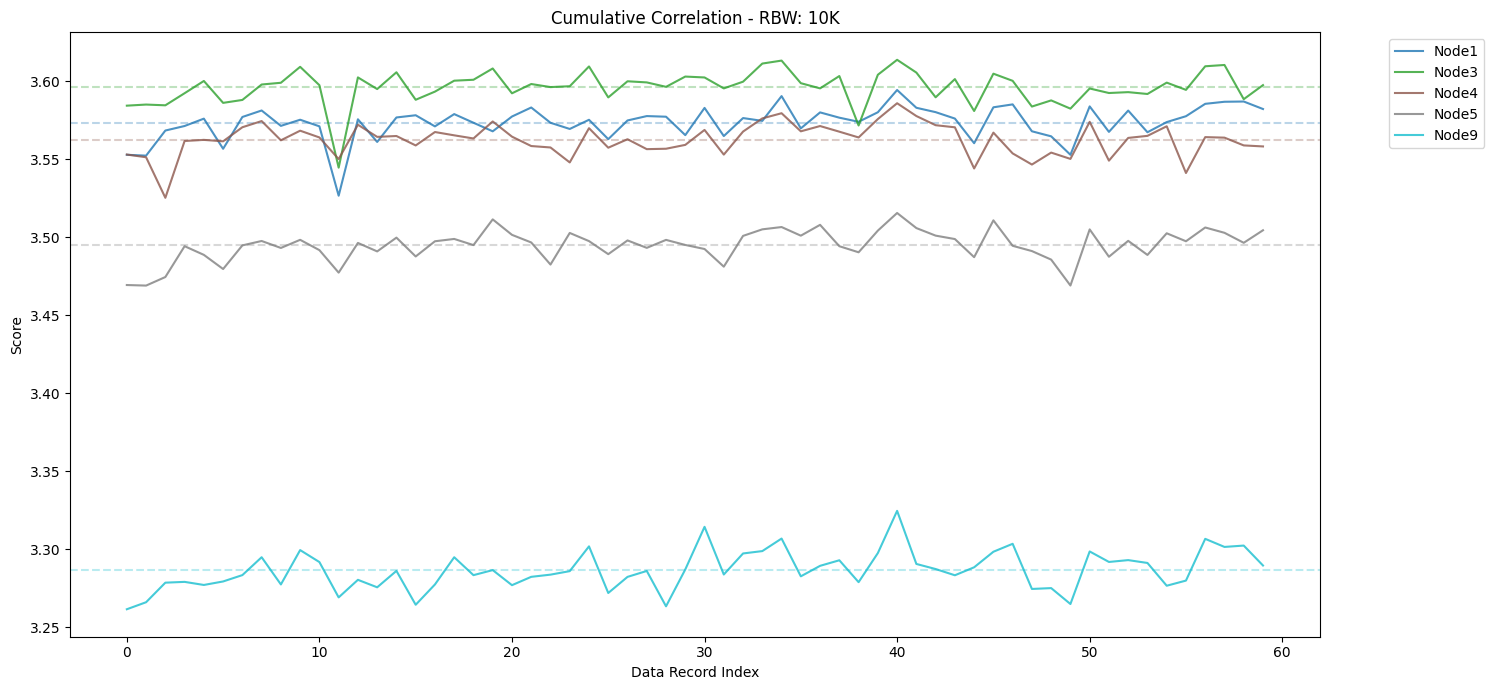

In [7]:
from scipy.stats import pearsonr

# 1. SELECCIÓN DE DATOS
RBW_TARGET = "10K"  # <--- Cambia aquí el RBW que quieras analizar
datos_nodos = df_full[RBW_TARGET]

# Determinar número de registros dinámicamente
num_records = len(next(iter(datos_nodos.values())))

all_ranked_scores = {}
all_cumulative_data = []

# =============================================================================
# LOOP: Procesamiento por cada registro
# =============================================================================
for data_record in tqdm(range(num_records), desc=f"Procesando {RBW_TARGET}"):

    pxx_indexed = {}
    noise_floor_estimates = {}

    # ── PASS 1: Noise floor + recentered PSDs ────────────────────────────────
    for nombre_nodo, df in datos_nodos.items():
        # pxx ya es una lista, solo la convertimos a array de numpy
        pxx = np.array(df['pxx'].iloc[data_record]) 
        pxx_indexed[nombre_nodo] = pxx

        counts, bins = np.histogram(pxx, bins=50)
        noise_floor_estimates[nombre_nodo] = bins[np.argmax(counts)]

    global_noise_mean = np.mean(list(noise_floor_estimates.values()))

    pxx_processed = {}
    for nombre_nodo in datos_nodos.keys():
        pxx_orig = pxx_indexed[nombre_nodo]
        offset = global_noise_mean - noise_floor_estimates[nombre_nodo]
        pxx_recentered = pxx_orig + offset
        pxx_processed[nombre_nodo] = (pxx_recentered - np.mean(pxx_recentered)) / (np.std(pxx_recentered) + 1e-8)

    # ── PASS 2: Pairwise Pearson correlation matrix ───────────────────────────
    node_names = sorted(datos_nodos.keys())
    n_nodes = len(node_names)
    corr_matrix = np.eye(n_nodes)

    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            corr_val, _ = pearsonr(pxx_processed[node_names[i]], pxx_processed[node_names[j]])
            corr_matrix[i, j] = corr_matrix[j, i] = corr_val

    # ── PASS 3: Cumulative scores ─────────────────────────────────────────────
    cumulative_scores = np.sum(corr_matrix, axis=1) - 1.0
    
    for node, score in zip(node_names, cumulative_scores):
        all_ranked_scores.setdefault(node, []).append(score)

# =============================================================================
# AVERAGE Y PLOT
# =============================================================================
avg_scores = {node: np.mean(scores) for node, scores in all_ranked_scores.items()}
avg_sorted = dict(sorted(avg_scores.items(), key=lambda x: x[1], reverse=True))

print(f"\n📊 Resultados para RBW: {RBW_TARGET}")
print("-" * 50)
for rank, (node, avg) in enumerate(avg_sorted.items(), 1):
    print(f"{rank:<3} | {node:<20} | Score: {avg:.4f} | Corr: {avg/(n_nodes-1):.4f}")

# Graficar
fig, ax = plt.subplots(figsize=(15, 7))
cmap = plt.cm.get_cmap('tab10', n_nodes)

for idx, node in enumerate(node_names):
    ax.plot(range(num_records), all_ranked_scores[node], label=node, color=cmap(idx), alpha=0.8)
    ax.axhline(y=avg_scores[node], color=cmap(idx), linestyle='--', alpha=0.3)

ax.set_title(f"Cumulative Correlation - RBW: {RBW_TARGET}")
ax.set_xlabel("Data Record Index")
ax.set_ylabel("Score")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4818a93-f2bf-4892-b7a2-47816cd4c47d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>